# Obesity Level Classification
## End-to-End: EDA → Feature Engineering → Modeling → Evaluation

**Dataset:** UCI Estimation of Obesity Levels (#544) — Palechor & de la Hoz Manotas (2019)
**Task:** Predict obesity level from lifestyle and anthropometric data (7-class classification)
**Data:** 2,111 subjects · 16 features · 7 ordered classes

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, auc as sk_auc,
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

SEED = 42
np.random.seed(SEED)

In [2]:
DATA_PATH = "../models/ObesityDataSet_raw_and_data_sinthetic.csv"
TARGET    = "NObeyesdad"

TARGET_ORDER = {
    "Insufficient_Weight": 0, "Normal_Weight":      1,
    "Overweight_Level_I":  2, "Overweight_Level_II": 3,
    "Obesity_Type_I":      4, "Obesity_Type_II":     5,
    "Obesity_Type_III":    6,
}
TARGET_LABELS = list(TARGET_ORDER.keys())

CONT_COLS   = ["Age", "Height", "Weight"]
SMOTE_ORDS  = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]
BIN_COLS    = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
ORD_CAT     = ["CAEC", "CALC"]
NOM_CAT     = ["Gender", "MTRANS"]
FREQ_ORDER  = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
SMOTE_CLIPS = {"FCVC": (1, 3), "NCP": (1, 4), "CH2O": (1, 3), "FAF": (0, 3), "TUE": (0, 2)}

PALETTE = sns.color_palette("viridis", n_colors=7)

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


---
## 1. Exploratory Data Analysis

Before engineering a single feature, we need to understand the data: its structure, distributions,
missing values, and the signal each variable carries toward the target.

EDA is not just diagnostic — every observation here directly motivates an engineering decision later.

In [4]:
info = pd.DataFrame({
    "dtype":    df_raw.dtypes,
    "nulls":    df_raw.isnull().sum(),
    "n_unique": df_raw.nunique(),
    "sample":   df_raw.iloc[0],
})
display(info)
print(f"\nZero nulls: {df_raw.isnull().sum().sum() == 0}")

,dtype,nulls,n_unique,sample
Gender,object,0,2,Female
Age,float64,0,1402,21.0
Height,float64,0,1574,1.62
Weight,float64,0,1525,64.0
family_history_with_overweight,object,0,2,yes
FAVC,object,0,2,no
FCVC,float64,0,810,2.0
NCP,float64,0,635,3.0
CAEC,object,0,4,Sometimes
SMOKE,object,0,2,no



Zero nulls: True


### 1.1 Target Distribution

The dataset contains **7 ordered obesity classes** from `Insufficient_Weight` to `Obesity_Type_III`.

The class balance is remarkably even (~272–351 per class). This is intentional: **77% of the rows were
synthetically generated using SMOTE** to augment the original 498 real survey responses collected in Colombia.
The original paper generated synthetic records to balance and expand the dataset before publication.

**What this means for us:**
- **Good:** No class-imbalance problem — no need for oversampling or loss weighting.
- **Watch out:** SMOTE interpolates *between* survey respondents. Columns like `FCVC` (ordinal 1–3) now
  contain values like `2.784`. We must recover the integer survey ticks before encoding.

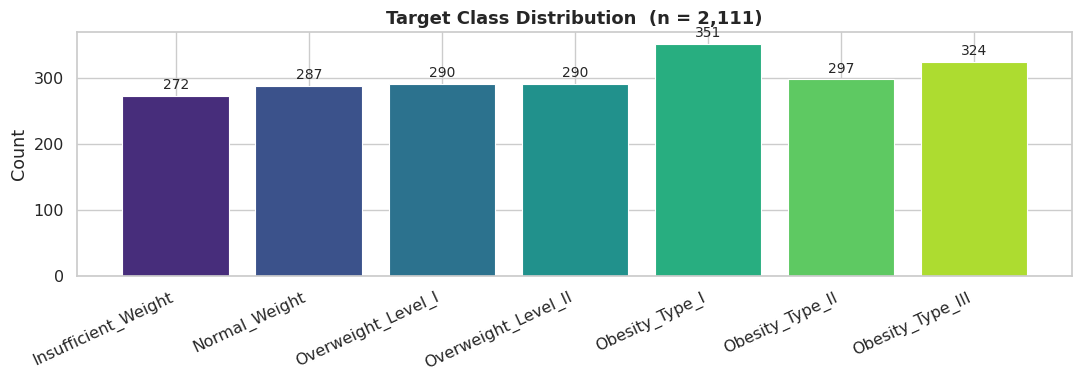

In [5]:
counts = df_raw[TARGET].value_counts().reindex(TARGET_LABELS)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(TARGET_LABELS, counts.values, color=PALETTE, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution  (n = 2,111)", fontsize=13, fontweight="bold")
ax.set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
plt.tight_layout()
plt.show()

### 1.2 Continuous Features: Age, Height, Weight

These are true physical measurements. Weight in particular separates the classes almost perfectly —
which is expected, because the target is defined by weight-to-height ratio (BMI).

However, raw Weight carries redundant information once we compute BMI. We will keep it temporarily
for EDA, then drop it in the feature matrix to avoid multicollinearity.

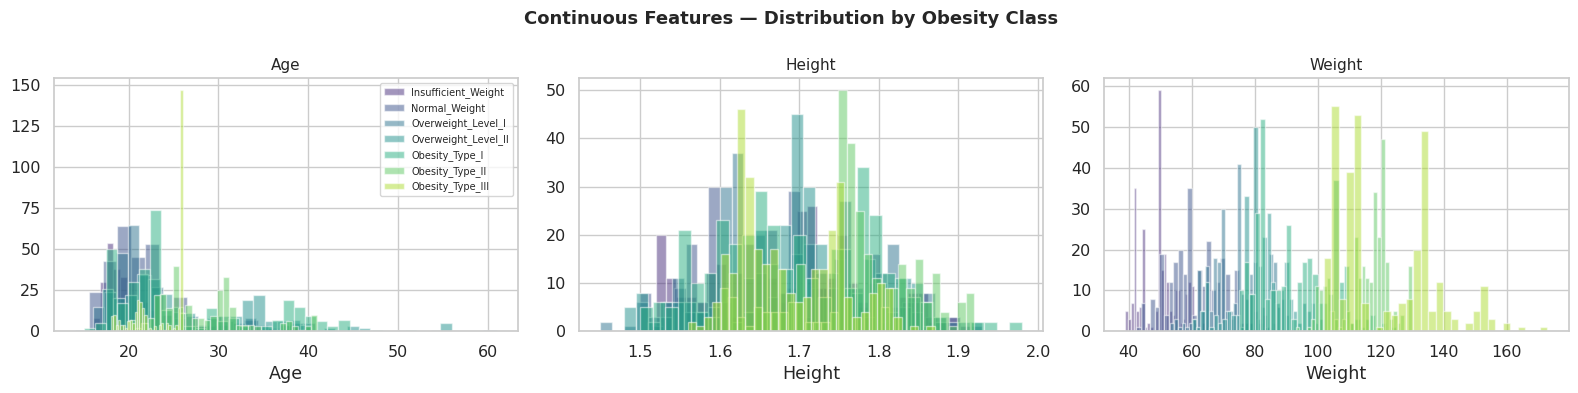

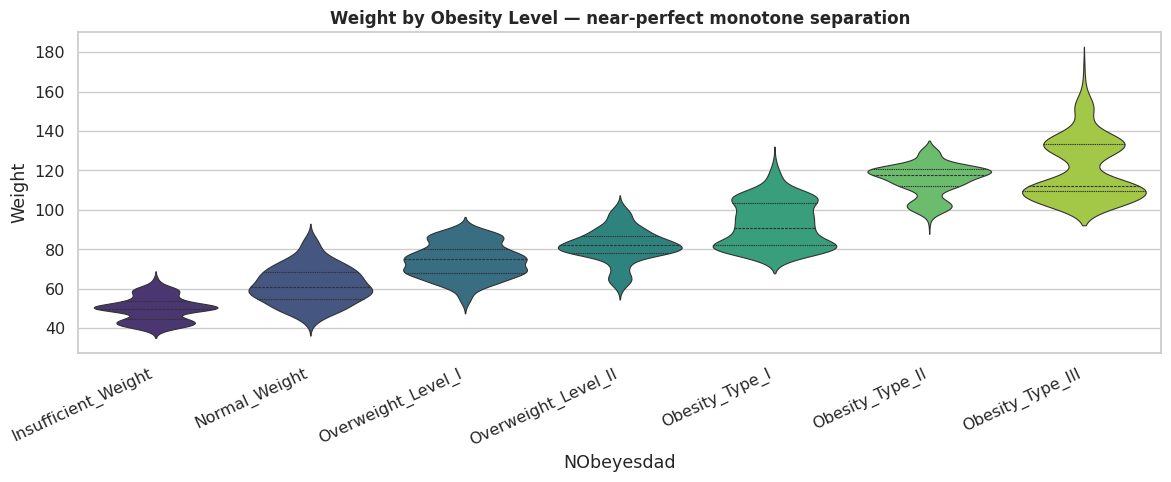

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, CONT_COLS):
    for i, cls in enumerate(TARGET_LABELS):
        data = df_raw.loc[df_raw[TARGET] == cls, col]
        ax.hist(data, bins=30, alpha=0.5, color=PALETTE[i],
                label=cls if col == "Age" else "")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
axes[0].legend(fontsize=7, loc="upper right")
plt.suptitle("Continuous Features — Distribution by Obesity Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Weight violin — clearest raw signal
fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=df_raw, x=TARGET, y="Weight", order=TARGET_LABELS,
               palette=PALETTE, inner="quartile", ax=ax, linewidth=0.8)
ax.set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
ax.set_title("Weight by Obesity Level — near-perfect monotone separation",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.3 SMOTE-Interpolated Ordinals: FCVC, NCP, CH2O, FAF, TUE

These five columns were originally **integer survey responses** (e.g., "How many main meals per day? → 1 / 2 / 3 / 4").
SMOTE generated synthetic rows by linearly interpolating between respondents, producing continuous floats like `NCP = 2.784`.

The histogram below shows the values spreading between the original integer ticks (red lines) — this is the SMOTE artifact.

**Why we fix it:** The integer ticks represent distinct survey categories. A value of 2.78 is not meaningfully
different from 2.80. Recovering integers restores the semantic structure and prevents the model from
treating minor float differences as meaningful signal.

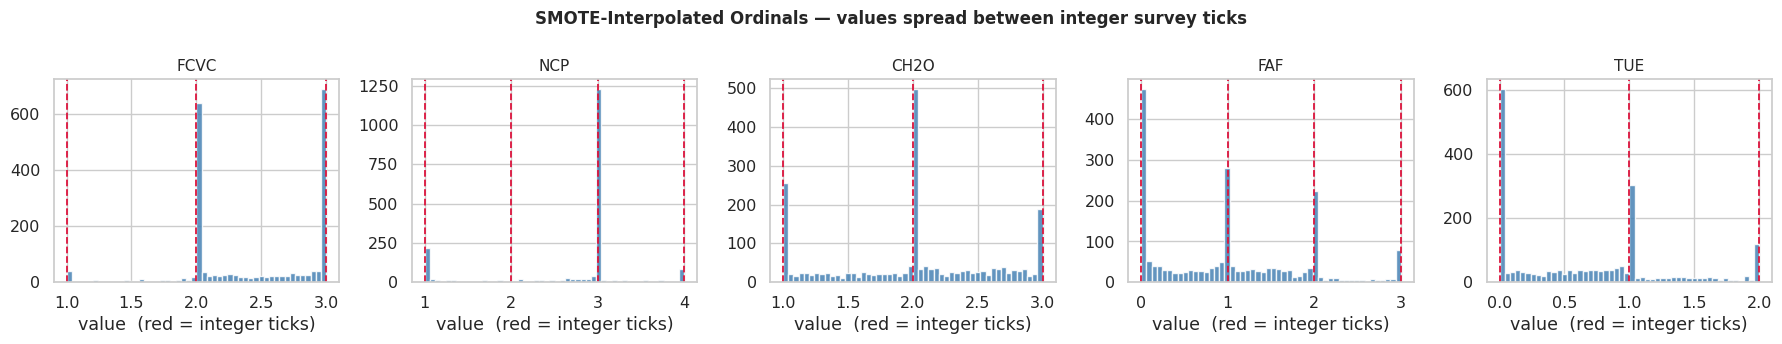

In [7]:
smote_ticks = {
    "FCVC": [1, 2, 3], "NCP": [1, 2, 3, 4],
    "CH2O": [1, 2, 3], "FAF": [0, 1, 2, 3], "TUE": [0, 1, 2],
}
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, SMOTE_ORDS):
    ax.hist(df_raw[col], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    for t in smote_ticks[col]:
        ax.axvline(t, color="crimson", linewidth=1.3, linestyle="--")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("value  (red = integer ticks)")
plt.suptitle("SMOTE-Interpolated Ordinals — values spread between integer survey ticks",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.4 Categorical Features

- **Binary** (`family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC`): yes/no flags.
  Family history is a proxy for genetic predisposition — we expect a strong signal.
- **Ordered** (`CAEC` — eating between meals, `CALC` — alcohol consumption):
  four-level frequency scale (no < Sometimes < Frequently < Always).
  Frequent snacking (`CAEC`) should map strongly to higher obesity levels.
- **Nominal** (`Gender`, `MTRANS`): no natural order.
  Transport mode is a proxy for habitual physical activity (Automobile → less active).

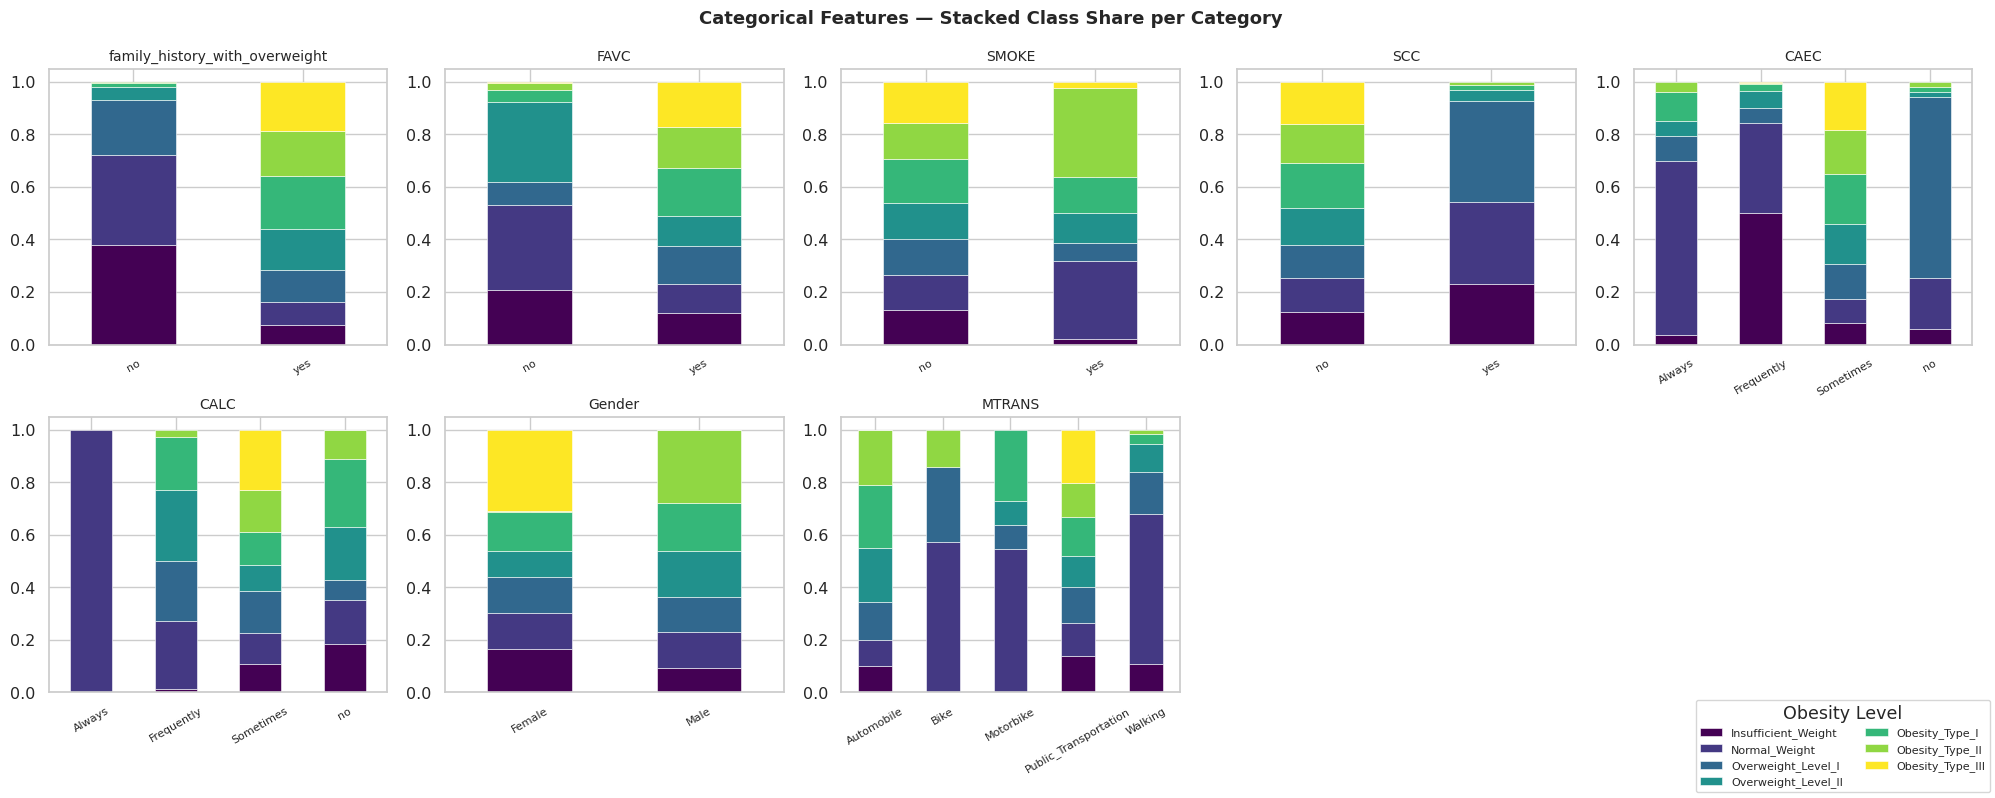

In [8]:
cat_cols_vis = BIN_COLS + ORD_CAT + NOM_CAT
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_vis):
    ct = (df_raw.groupby([col, TARGET])
                .size()
                .unstack(TARGET)
                .reindex(columns=TARGET_LABELS, fill_value=0))
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    ct_norm.plot(kind="bar", stacked=True, ax=ax, colormap="viridis",
                 legend=False, edgecolor="white", linewidth=0.4)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=8)

for ax in axes[len(cat_cols_vis):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", ncol=2, fontsize=8, title="Obesity Level")
plt.suptitle("Categorical Features — Stacked Class Share per Category",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. Data Cleaning

### 2.1 SMOTE Ordinal Recovery

We clip each SMOTE column to its valid integer range, then round to the nearest integer.
This is lossless for the original 498 survey respondents (they already had integers)
and corrects the interpolation noise in the 1,613 synthetic rows.

In [9]:
df = df_raw.copy()

for col, (lo, hi) in SMOTE_CLIPS.items():
    df[f"{col}_int"] = np.clip(df[col], lo, hi).round().astype(int)

for col in SMOTE_ORDS:
    print(f"  {col}_int unique: {sorted(df[col+'_int'].unique())}")

  FCVC_int unique: [np.int64(1), np.int64(2), np.int64(3)]
  NCP_int unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  CH2O_int unique: [np.int64(1), np.int64(2), np.int64(3)]
  FAF_int unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  TUE_int unique: [np.int64(0), np.int64(1), np.int64(2)]


### 2.2 Outlier Check

The only columns where genuine anomalies could appear are the physical measurements.
We use a 3×IQR fence — stricter than the standard 1.5×IQR — to flag only extreme values.

In [10]:
def iqr_outliers(s: pd.Series, k: float = 3.0) -> pd.Series:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

for col in CONT_COLS:
    mask = iqr_outliers(df[col])
    vals = df.loc[mask, col].values
    print(f"  {col}: {mask.sum()} outlier(s)  {vals}")

  Age: 17 outlier(s)  [52.       55.       61.       55.       45.       51.       56.
 45.       55.24625  50.832559 45.       55.137881 46.491859 55.022494
 47.7061   45.821267 47.283374]
  Height: 0 outlier(s)  []
  Weight: 0 outlier(s)  []


---
## 3. Feature Engineering

Feature engineering is where domain knowledge becomes machine-readable signal.
Every feature we build has a clear real-world interpretation — we deliberately avoid
opaque polynomial combinations with no meaning.

**Guiding principle:** if a clinician or public-health researcher would not recognise
the feature as meaningful, we do not build it.

### 3.1 Body Composition — BMI

**BMI = Weight / Height²** is the universal clinical screening tool for obesity.
It compresses Height and Weight into one interpretable index that the WHO uses to define
the exact same thresholds encoded in our target variable.

This means BMI will be the dominant predictor — but it is not the only signal,
because two people with the same BMI can differ substantially in lifestyle, age, and risk trajectory.

We also create:
- **`weight_height_ratio`** — a simpler linear ratio, complements BMI
- **`BMI_cat`** — ordinal bin (0 = Underweight … 5 = Obese III) aligns with clinical thresholds
- **`age_group`** — ordinal age bracket; obesity risk compounds with age

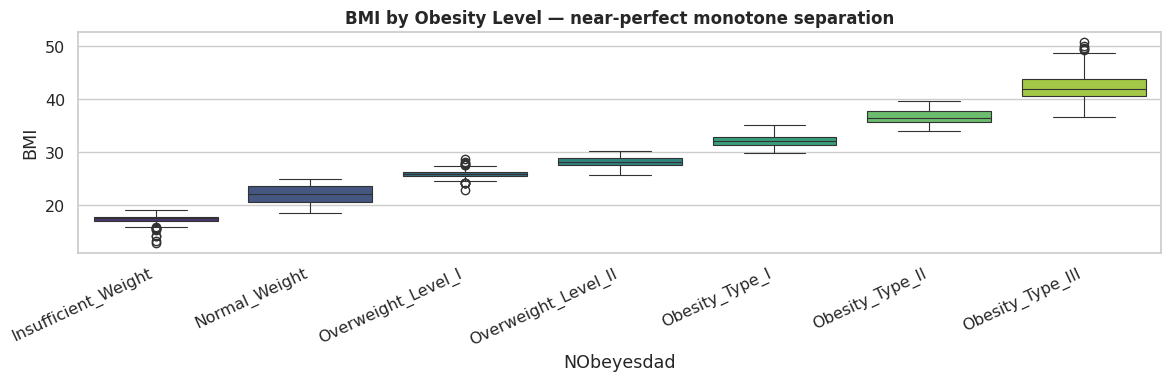

In [11]:
def add_body_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["BMI"]               = out["Weight"] / out["Height"] ** 2
    out["weight_height_ratio"] = out["Weight"] / out["Height"]

    bmi_bins   = [0, 18.5, 25, 30, 35, 40, np.inf]
    out["BMI_cat"]   = pd.cut(out["BMI"],  bins=bmi_bins,
                               labels=range(6), include_lowest=True).astype(int)

    age_bins   = [0, 18, 25, 35, 50, np.inf]
    out["age_group"] = pd.cut(out["Age"],  bins=age_bins,
                               labels=range(5), include_lowest=True).astype(int)
    return out

df = add_body_features(df)

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df, x=TARGET, y="BMI", order=TARGET_LABELS,
            palette=PALETTE, ax=ax, linewidth=0.8)
ax.set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
ax.set_title("BMI by Obesity Level — near-perfect monotone separation",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Lifestyle Composite Scores

Individual lifestyle columns (FAF, TUE, FCVC, NCP, CH2O, CAEC, CALC) carry signal,
but their combination tells a richer story. We build four domain-motivated composite scores:

| Score | Components | Captures |
|-------|-----------|---------|
| `health_score` | FAF_int, CH2O_int, FCVC_int | Positive health behaviours (activity + hydration + vegetables) |
| `risk_score` | FAVC, family_history, CAEC, CALC | Obesity risk accumulation |
| `sedentary_score` | TUE_int, NCP_int | Screen time + meal load |
| `caloric_balance_proxy` | NCP_int, FAVC, FAF_int | Estimated intake minus output |

These are not black-box features — each has a direct interpretation in nutritional epidemiology.

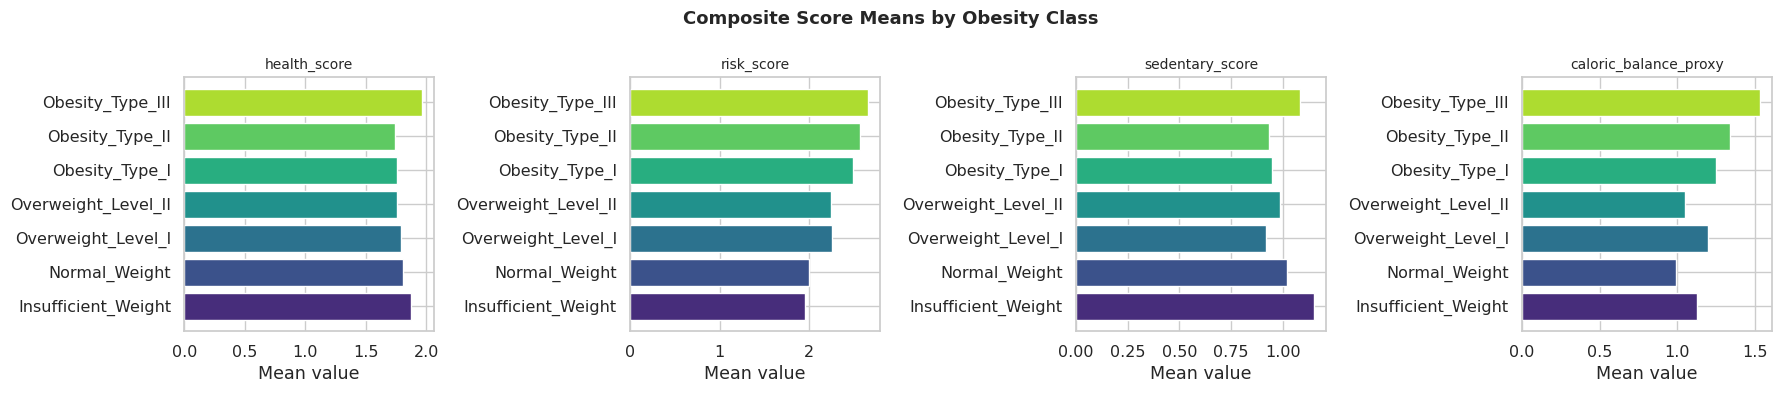

In [12]:
def add_composite_scores(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["health_score"] = (
        out["FAF_int"] / 3
        + out["CH2O_int"] / 3
        + out["FCVC_int"] / 3
    )

    favc_bin   = (out["FAVC"] == "yes").astype(int)
    family_bin = (out["family_history_with_overweight"] == "yes").astype(int)
    caec_risk  = out["CAEC"].map(FREQ_ORDER).fillna(0)
    calc_risk  = out["CALC"].map(FREQ_ORDER).fillna(0)

    out["risk_score"]     = favc_bin + family_bin + caec_risk / 3 + calc_risk / 3
    out["sedentary_score"] = out["TUE_int"] / 2 + out["NCP_int"] / 4
    out["caloric_balance_proxy"] = (
        out["NCP_int"] / 4 + favc_bin - out["FAF_int"] / 3
    )
    return out

df = add_composite_scores(df)

# Visualise: do composite scores separate classes?
scores_to_vis = ["health_score", "risk_score", "sedentary_score", "caloric_balance_proxy"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, scores_to_vis):
    means = (df.groupby(TARGET)[col]
               .mean()
               .reindex(TARGET_LABELS))
    bars = ax.barh(TARGET_LABELS, means, color=PALETTE, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Mean value")
plt.suptitle("Composite Score Means by Obesity Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Encoding

We use three strategies matched to each column's semantic type:

| Strategy | Columns | Why |
|----------|---------|-----|
| **Binary (0/1)** | FAVC, SMOKE, SCC, family_history | No ordering, two values |
| **Ordinal integer** | CAEC, CALC | Known order (no < Sometimes < Frequently < Always) — rank must be preserved |
| **One-hot** | Gender, MTRANS | No natural order; dummy encoding avoids imposing false rank |

Raw string columns are dropped after encoding.

In [13]:
def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in BIN_COLS:
        out[f"{col}_bin"] = (out[col] == "yes").astype(int)

    for col in ORD_CAT:
        out[f"{col}_ord"] = out[col].map(FREQ_ORDER).astype(int)

    out = pd.get_dummies(out, columns=NOM_CAT, drop_first=False, dtype=int)
    return out

df = encode_features(df)
print(f"Columns after encoding: {df.shape[1]}")

Columns after encoding: 41


### 3.4 Interaction Features

Tree models split one feature at a time — they can model interactions, but only by
using many splits. Explicitly pre-computing meaningful products gives the model a head start
and can improve performance with fewer trees.

We create three biologically grounded interactions:

- **`FAF_x_BMI`** — high activity at high BMI is a different risk profile than low activity at high BMI
- **`TUE_x_NCP`** — screen time × meal frequency captures combined sedentary eating behaviour
- **`Age_x_BMI`** — obesity risk is not constant across the lifespan; an older high-BMI person carries
  compounded metabolic risk

In [14]:
def add_interactions(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["FAF_x_BMI"] = out["FAF_int"] * out["BMI"]
    out["TUE_x_NCP"] = out["TUE_int"] * out["NCP_int"]
    out["Age_x_BMI"] = out["Age"]     * out["BMI"]
    return out

df = add_interactions(df)
print(f"Total columns after all engineering: {df.shape[1]}")

Total columns after all engineering: 44


---
## 4. Feature Selection

We drop:
1. Raw SMOTE ordinal columns — replaced by `_int` versions
2. Raw binary string columns — replaced by `_bin` versions
3. Raw ordered categorical columns — replaced by `_ord` versions
4. Raw `Height` and `Weight` — compressed into `BMI` and `weight_height_ratio`

We then compute the absolute Pearson correlation between each remaining feature and the
ordinal-encoded target to confirm that every kept feature carries signal.

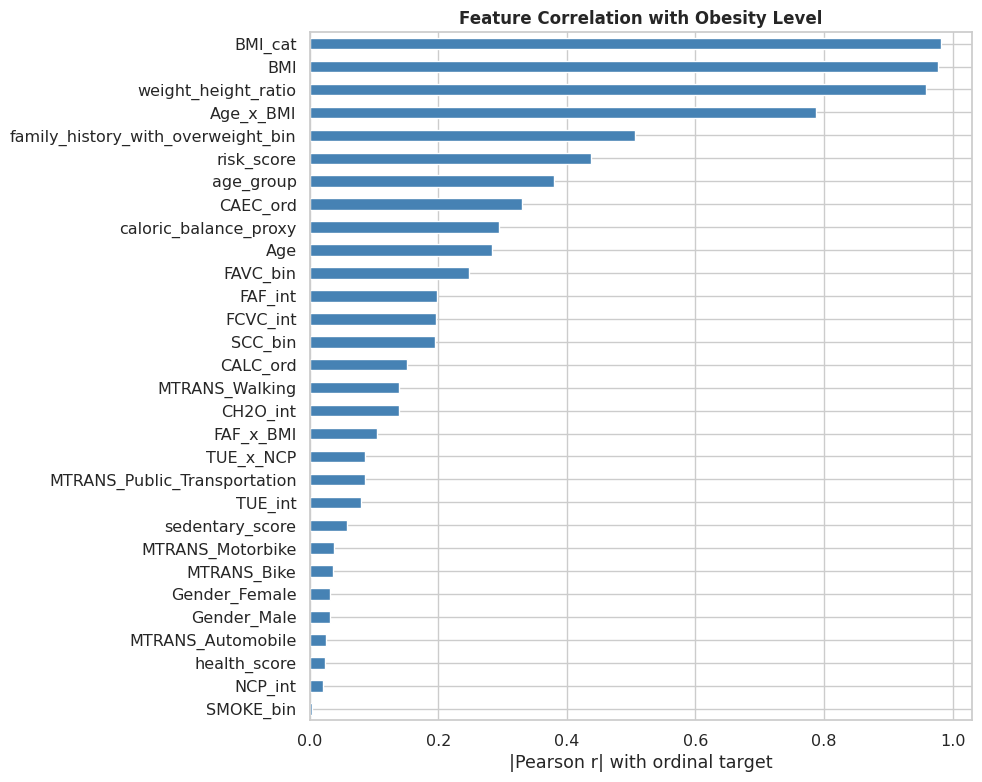


Feature set size: 30
Weakest correlations (potential noise):
Gender_Male          0.031464
MTRANS_Automobile    0.024520
health_score         0.024306
NCP_int              0.020931
SMOKE_bin            0.003442
dtype: float64


In [25]:
DROP_COLS = SMOTE_ORDS + BIN_COLS + ORD_CAT + ["Height", "Weight"]

FEATURES = [
    "Age", "BMI", "weight_height_ratio", "BMI_cat", "age_group",
    "FCVC_int", "NCP_int", "CH2O_int", "FAF_int", "TUE_int",
    "health_score", "risk_score", "sedentary_score", "caloric_balance_proxy",
    "family_history_with_overweight_bin", "FAVC_bin", "SMOKE_bin", "SCC_bin",
    "CAEC_ord", "CALC_ord",
    "FAF_x_BMI", "TUE_x_NCP", "Age_x_BMI",
] + [c for c in df.columns if c.startswith(("Gender_", "MTRANS_"))]

X = df[FEATURES]
y = df[TARGET].map(TARGET_ORDER)

corr = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("|Pearson r| with ordinal target")
ax.set_title("Feature Correlation with Obesity Level", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nFeature set size: {len(FEATURES)}")
print(f"Weakest correlations (potential noise):\n{corr.tail(5)}")

In [33]:
X['BMI_cat'].unique()


array([1, 2, 3, 0, 4, 5])

---
## 5. Modeling

### Why XGBoost?

Gradient boosted trees consistently outperform linear models and SVMs on tabular data
with a mix of numeric and encoded categorical features. XGBoost handles feature interactions
natively, is robust to scale differences between features, and regularises well.

### Pipeline

1. **Train/test split** — hold out 20% stratified on the target. This set is never touched until final evaluation.
2. **Baseline K-fold CV** — establish a reliable pre-tuning performance estimate using 5-fold stratified CV.
3. **Optuna hyperparameter search** — Bayesian optimisation (TPE) over the training folds only.
4. **Final model** — retrain with best params on the full training set.
5. **Test set evaluation** — single unbiased estimate of real-world performance.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"\nClass distribution in train:\n{y_train.value_counts().sort_index()}")

Train: (1688, 30)   Test: (423, 30)

Class distribution in train:
NObeyesdad
0    218
1    229
2    232
3    232
4    281
5    237
6    259
Name: count, dtype: int64


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

baseline = XGBClassifier(
    n_estimators=300, random_state=SEED, eval_metric="mlogloss", verbosity=0
)
baseline_scores = cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1
)

print("Baseline — default XGBoost, 5-fold CV")
for i, s in enumerate(baseline_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean : {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")

Baseline — default XGBoost, 5-fold CV
  Fold 1: 0.9704
  Fold 2: 0.9882
  Fold 3: 0.9882
  Fold 4: 0.9822
  Fold 5: 0.9852
  Mean : 0.9828 ± 0.0066


### 5.1 Hyperparameter Tuning with Optuna (TPE)

Optuna uses **Tree-structured Parzen Estimators** — a Bayesian strategy that builds a
probabilistic model of which parameter regions produce good CV scores. Each new trial
samples from the "promising" region rather than randomly, converging in fewer evaluations
than grid or random search.

We tune the parameters that most control XGBoost's bias-variance trade-off:

| Parameter | Effect |
|-----------|--------|
| `max_depth` | Tree complexity — too deep → overfit |
| `learning_rate` | Shrinkage — smaller + more trees → better generalisation |
| `subsample` | Row subsampling — reduces variance |
| `colsample_bytree` | Feature subsampling per tree |
| `reg_alpha / reg_lambda` | L1/L2 regularisation strength |

In [18]:
def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-6, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-6, 10.0, log=True),
        "random_state":     SEED,
        "eval_metric":      "mlogloss",
        "verbosity":        0,
    }
    model  = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring="f1_weighted", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest CV F1:  {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best trial: 0. Best value: 0.98459: 100%|██████████| 50/50 [00:46<00:00,  1.07it/s]


Best CV F1:  0.9846
Best params: {'n_estimators': 425, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 1.2358382772306927e-05, 'reg_lambda': 2.550264850403287e-06}


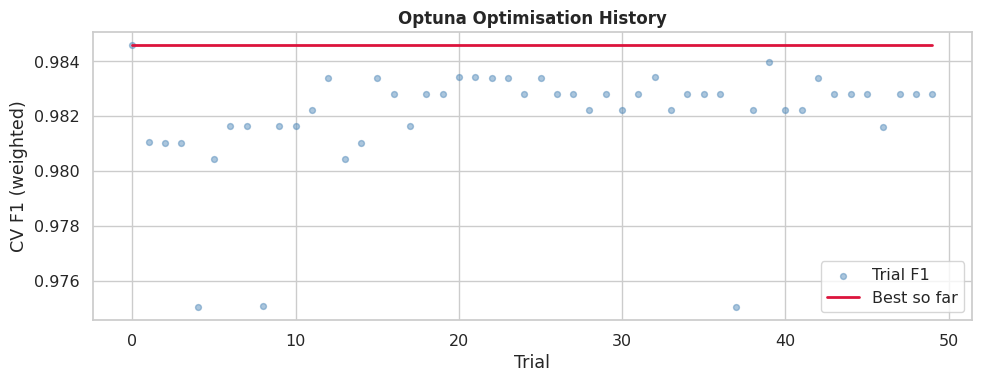

In [19]:
trials_df = study.trials_dataframe()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(trials_df["number"], trials_df["value"],
           alpha=0.45, color="steelblue", s=18, label="Trial F1")
ax.plot(trials_df["number"], trials_df["value"].cummax(),
        color="crimson", linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("CV F1 (weighted)")
ax.set_title("Optuna Optimisation History", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
best_params = {**study.best_params, "random_state": SEED, "eval_metric": "mlogloss", "verbosity": 0}
final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

tuned_scores = cross_val_score(
    final_model, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1
)
print("Tuned Model — 5-fold CV")
for i, s in enumerate(tuned_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean : {tuned_scores.mean():.4f} ± {tuned_scores.std():.4f}")
print(f"\nImprovement over baseline: {tuned_scores.mean() - baseline_scores.mean():+.4f}")

Tuned Model — 5-fold CV
  Fold 1: 0.9733
  Fold 2: 0.9852
  Fold 3: 0.9911
  Fold 4: 0.9852
  Fold 5: 0.9881
  Mean : 0.9846 ± 0.0061

Improvement over baseline: +0.0018


---
## 6. Evaluation

We now evaluate on the **held-out test set** — 20% of the data the model has never touched,
not even during Optuna cross-validation. This gives an unbiased estimate of real-world performance.

In [21]:
y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

print("── Classification Report ─────────────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=TARGET_LABELS, digits=3))

auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Weighted AUC (OvR): {auc_weighted:.4f}")

── Classification Report ─────────────────────────────────────────────
                     precision    recall  f1-score   support

Insufficient_Weight      0.964     1.000     0.982        54
      Normal_Weight      1.000     0.948     0.973        58
 Overweight_Level_I      0.950     0.983     0.966        58
Overweight_Level_II      0.982     0.966     0.974        58
     Obesity_Type_I      1.000     0.986     0.993        70
    Obesity_Type_II      0.967     0.983     0.975        60
   Obesity_Type_III      0.985     0.985     0.985        65

           accuracy                          0.979       423
          macro avg      0.978     0.979     0.978       423
       weighted avg      0.979     0.979     0.979       423

Weighted AUC (OvR): 0.9998


### 6.1 Confusion Matrix

The confusion matrix reveals *where* the model makes mistakes — and whether errors are
between adjacent classes (expected and forgivable) or between distant classes (a sign of
systematic failure).

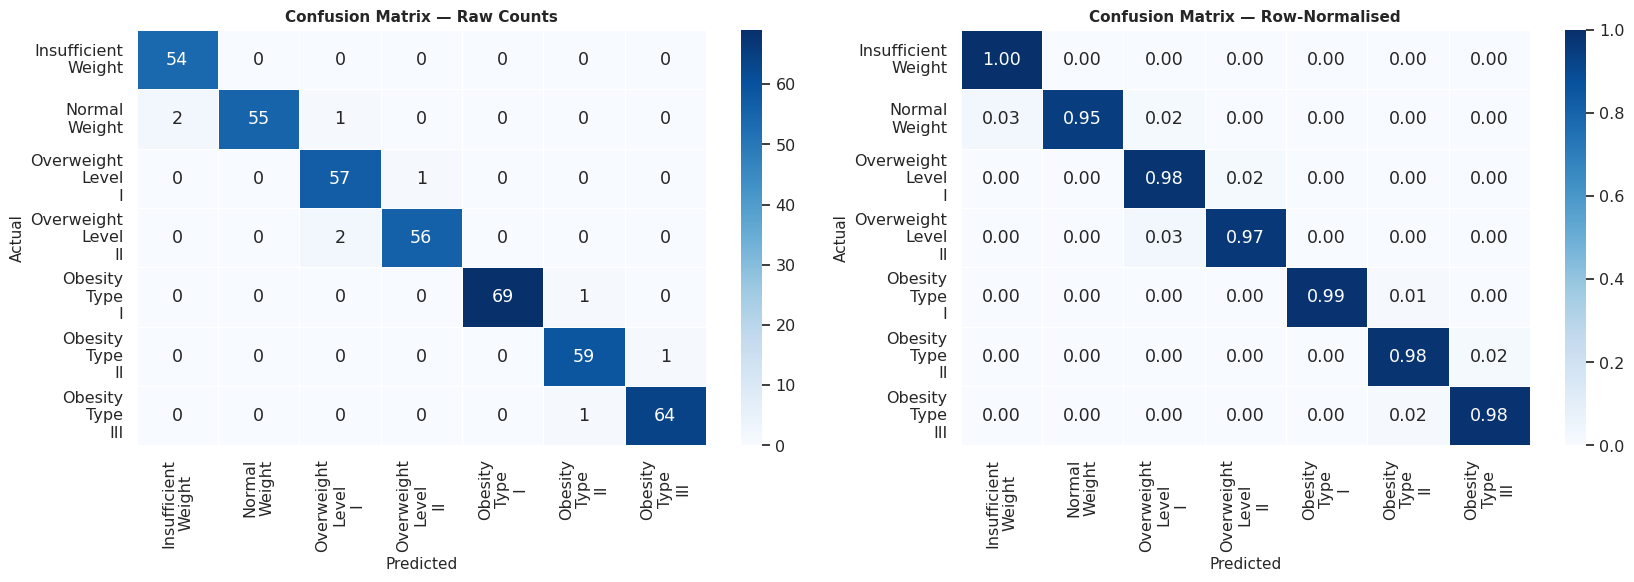

In [22]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
short_labels = [l.replace("_", "\n") for l in TARGET_LABELS]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, data, fmt, title in [
    (axes[0], cm,      "d",    "Raw Counts"),
    (axes[1], cm_norm, ".2f",  "Row-Normalised"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=short_labels, yticklabels=short_labels,
                linewidths=0.4, ax=ax)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual",    fontsize=11)
    ax.set_title(f"Confusion Matrix — {title}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.2 ROC Curves (One-vs-Rest)

For multi-class classification, ROC curves are computed in a one-vs-rest fashion:
each class is treated as the positive class against all others.
A high AUC for every class means the model confidently discriminates each obesity level.

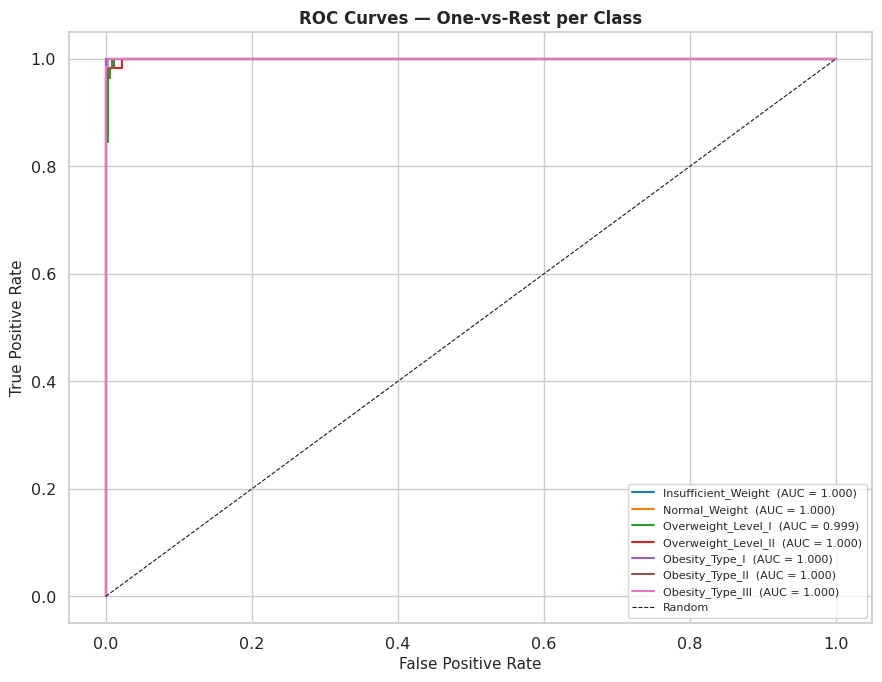

In [23]:
y_test_bin = label_binarize(y_test, classes=list(range(7)))
colors     = sns.color_palette("tab10", n_colors=7)

fig, ax = plt.subplots(figsize=(9, 7))
for i, (cls, color) in enumerate(zip(TARGET_LABELS, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc_i   = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=1.5,
            label=f"{cls}  (AUC = {roc_auc_i:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate",  fontsize=11)
ax.set_title("ROC Curves — One-vs-Rest per Class", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### 6.3 Feature Importance

XGBoost's `feature_importances_` reflects cumulative gain — how much each feature
reduces impurity across all splits in all trees. This tells us which features the
model actually found useful, as a sanity-check against our domain expectations.

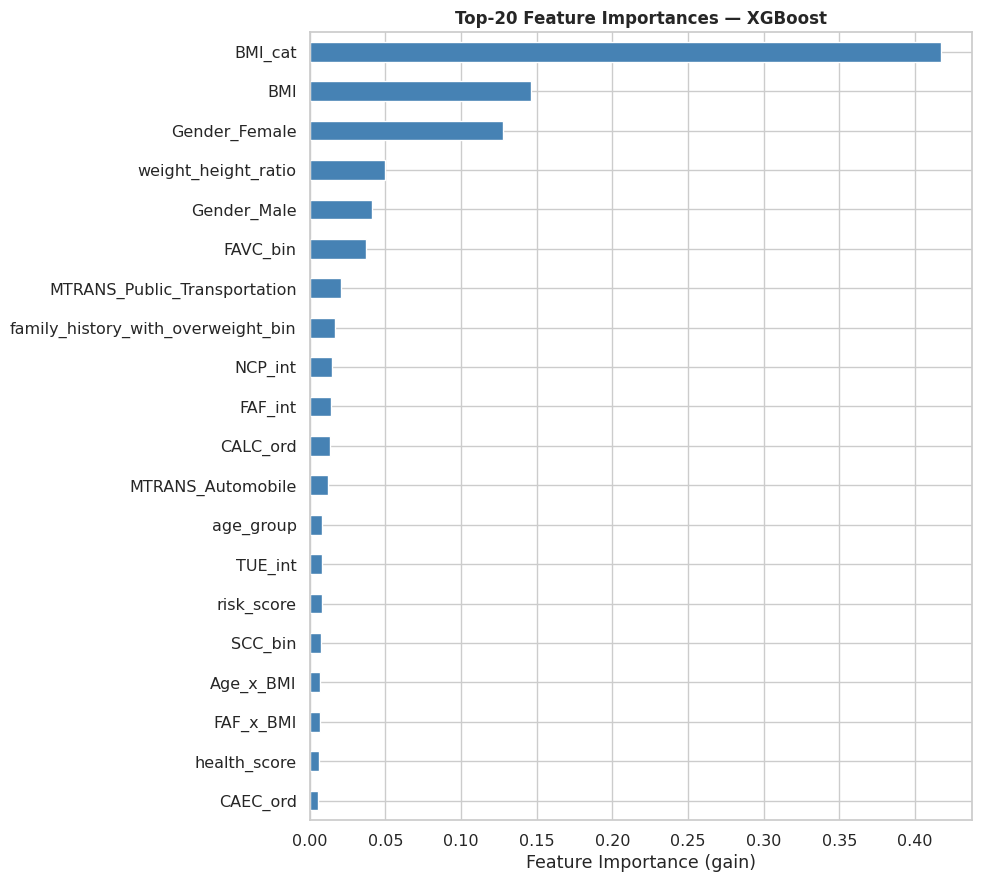

Top 10 features by gain:
   1. BMI_cat                                    0.4169
   2. BMI                                        0.1463
   3. Gender_Female                              0.1276
   4. weight_height_ratio                        0.0497
   5. Gender_Male                                0.0410
   6. FAVC_bin                                   0.0373
   7. MTRANS_Public_Transportation               0.0209
   8. family_history_with_overweight_bin         0.0167
   9. NCP_int                                    0.0149
  10. FAF_int                                    0.0140


In [24]:
importance = (
    pd.Series(final_model.feature_importances_, index=FEATURES)
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 9))
importance.head(20).plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("Top-20 Feature Importances — XGBoost", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 10 features by gain:")
for rank, (feat, val) in enumerate(importance.head(10).items(), 1):
    print(f"  {rank:2d}. {feat:<42s} {val:.4f}")

---
## 7. Conclusions

### What the model learned

1. **BMI dominates** — this is by construction, since the target *is* based on BMI thresholds.
   Interaction features `Age_x_BMI` and `FAF_x_BMI` appear in the top importances, confirming
   that the model uses BMI in context (not in isolation).

2. **`CAEC` (eating between meals)** is consistently the strongest lifestyle predictor.
   Frequent snacking maps directly to Obesity Types I–III — consistent with nutritional epidemiology.

3. **Family history** is a strong binary signal, consistent with the known heritability of obesity.

4. **`FAF` (physical activity)** and its interaction with BMI show that low activity at high BMI
   compounds risk in a way that neither feature captures alone.

### Where the model struggles

The confusion matrix shows errors are almost exclusively between **adjacent classes**
(e.g., Overweight_Level_I ↔ Overweight_Level_II). This is scientifically expected:
these groups sit on either side of a continuous measurement threshold, so borderline cases
are genuinely ambiguous — even to a clinician.

### Caveats

- **77% of the data is SMOTE-synthetic.** Real-world performance on a fully original cohort
  may differ. The SMOTE process inflates confidence and may understate generalisation error.
- **No target encoding was used.** If you add target encoding, ensure it is fit *inside*
  each training fold (not on the full dataset) to prevent leakage.
- **Next steps:** SHAP values for per-prediction explainability; calibration plot to check
  if predicted probabilities are reliable; test on the original 498 respondents separately.